In [2]:
import pandas as pd

df = pd.read_csv("train-labels.csv")

charset = sorted(set("".join(df.iloc[:,1].astype(str))))

print(charset)
print("Total:", len(charset))

['-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'g', 'i', 'n', 'p', 'r', 't']
Total: 19


In [3]:
print(df.head())
print(df.columns)

   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR
Index(['Unnamed: 0', 'image', 'text'], dtype='str')


In [4]:
charset = sorted(set("".join(df["text"].astype(str))))

print(charset)
print("Total:", len(charset))

['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Total: 38


In [5]:
print(df["text"].head(20))

0     BU522X
1     XQ8NE2
2     DTZD3E
3     SM424H
4     6YVTQR
5     YV2C3D
6     XNBP7G
7     TGQXFU
8     36B667
9     QJ6HDR
10    37NJTE
11    5ENJJN
12    A62MEZ
13    TQNGEQ
14    UV8VKS
15    JQHJY8
16    DQEGSW
17    8FRWRA
18    RM5R3A
19    5RFZEP
Name: text, dtype: str


In [6]:
print(df["text"].str.len().value_counts())

text
6    19998
8        1
9        1
Name: count, dtype: int64


In [7]:
special = sorted(set("".join(df["text"])) - set("ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"))
print(special)

['+', '-', '.', 'a', 'r']


In [8]:
bad = df[df["text"].str.len() != 6]
print(bad)

      Unnamed: 0           image       text
2184        2184  train-2184.png   5.40E+12
6819        6819  train-6819.png  04-Mar-54


In [9]:
df = df[df["text"].str.len() == 6].reset_index(drop=True)

In [10]:
print(df.loc[2184])
print(df.loc[6819])

Unnamed: 0              2185
image         train-2185.png
text                  VQWHF8
Name: 2184, dtype: object
Unnamed: 0              6821
image         train-6821.png
text                  XWB5TR
Name: 6819, dtype: object


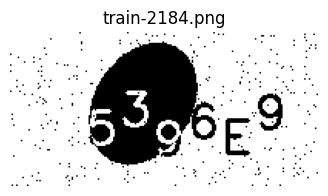

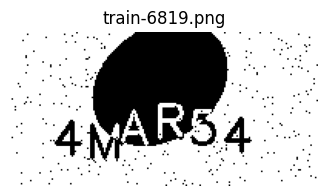

In [12]:
import cv2
import matplotlib.pyplot as plt

for img_name in ["train-2184.png", "train-6819.png"]:
    img = cv2.imread(f"train_images/{img_name}", cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(6,2))
    plt.imshow(img, cmap="gray")
    plt.title(img_name)
    plt.axis("off")
    plt.show()

In [14]:
df.loc[df["image"] == "train-2184.png", "text"] = "5396E9"
df.loc[df["image"] == "train-6819.png", "text"] = "4MARS4"

In [15]:
print(df[df["image"].isin(["train-2184.png", "train-6819.png"])])

Empty DataFrame
Columns: [Unnamed: 0, image, text]
Index: []


In [16]:
charset = sorted(set("".join(df["text"])))
print(charset)
print("Total:", len(charset))

['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total: 31


In [17]:
from collections import Counter

chars = "".join(df["text"])
freq = Counter(chars)

for k,v in sorted(freq.items()):
    print(k, v)

2 3925
3 3826
4 3881
5 3830
6 3842
7 3989
8 3811
9 3746
A 3819
B 3805
C 3861
D 3880
E 3965
F 3913
G 3942
H 3845
J 3886
K 3753
M 3925
N 3904
P 3836
Q 3873
R 3883
S 3889
T 3841
U 3812
V 3838
W 3916
X 3956
Y 3936
Z 3860


In [18]:
from PIL import Image
import os

sizes = set()

for img_file in os.listdir("train_images"):
    img = Image.open(os.path.join("train_images", img_file))
    sizes.add(img.size)

print(sizes)

{(200, 100)}


In [19]:
all_chars = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

present = set("".join(df["text"]))

missing = sorted(set(all_chars) - present)

print(missing)

['0', '1', 'I', 'L', 'O']
